# Buổi 4 · Perceptron phân loại phân khúc nhà

**Case study thực tế:** từ thông tin vị trí và đặc điểm căn nhà, xây một node nơ-ron cơ bản để dự đoán căn nhà thuộc nhóm **giá/m² cao** hay **phổ thông**. Node này có thể được ghép với các node khác trong một mạng nơ-ron lớn hơn.

## Tình huống

Một nhóm phân tích cần sàng lọc nhanh danh sách nhà trước khi chuyên viên xem chi tiết. Ta dùng ngưỡng **85 triệu đồng/m²** để tạo nhãn học:

- `0` — Phổ thông: giá/m² dưới 85 triệu đồng.
- `1` — Giá/m² cao: giá/m² từ 85 triệu đồng trở lên.

Sau bài này, bạn có thể: chuẩn bị feature số và phân loại; chia train/test; huấn luyện Perceptron; đọc confusion matrix; giải thích `net = wᵀx + b`; và nhận ra data leakage.

> Dữ liệu trong repo là dữ liệu mô phỏng phục vụ học tập, không phải dữ liệu định giá thị trường.

In [13]:
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ROOT = Path.cwd()
if not (ROOT / 'data' / 'sample_houses.csv').exists():
    ROOT = ROOT.parent

script_path = ROOT / 'bai-tap' / 'buoi4_perceptron_phan_khuc_nha.py'
spec = spec_from_file_location('buoi4_housing', script_path)
case = module_from_spec(spec)
sys.modules[spec.name] = case
assert spec.loader is not None
spec.loader.exec_module(case)

pd.set_option('display.max_columns', 20)

## 1. Đọc dữ liệu và tạo nhãn

CSV đã nằm trong `data/sample_houses.csv`, nên notebook chạy được khi không có Internet. Hãy đọc 5 dòng đầu và kiểm tra ý nghĩa từng cột trước khi huấn luyện.

In [14]:
THRESHOLD = 85.0
data = case.load_housing_data(ROOT / 'data' / 'sample_houses.csv', threshold=THRESHOLD)
print(f'Số dòng: {len(data)} | Số cột: {data.shape[1]}')
data.head()

Số dòng: 150 | Số cột: 12


,id,city,district,area_m2,bedrooms,bathrooms,floors,building_type,year_built,price_million_vnd,price_per_m2_million_vnd,phan_khuc_cao
0,1,Ho Chi Minh City,Quan 9,144.1,3,1,5,townhouse,2022,8937.19,62.02,0
1,2,Ho Chi Minh City,Quan 7,133.9,4,3,5,house,2005,11187.61,83.55,0
2,3,Ha Noi,Dong Da,52.0,4,2,5,apartment,2009,3550.30,68.28,0
3,4,Ha Noi,Dong Da,146.9,3,2,3,townhouse,2024,12626.00,85.95,1
4,5,Ho Chi Minh City,Thu Duc,102.9,1,1,2,apartment,2017,7266.38,70.62,0


In [15]:
class_counts = (
    data[case.TARGET_COLUMN]
    .map(case.CLASS_NAMES)
    .value_counts()
    .rename_axis('nhãn')
    .to_frame('số mẫu')
)
class_counts['tỷ lệ'] = (class_counts['số mẫu'] / len(data)).round(3)
class_counts

,số mẫu,tỷ lệ
nhãn,,
Phổ thông,101,0.673
Giá/m² cao,49,0.327


### Điểm dừng · Vì sao không dùng cột giá?

Nhãn được tạo trực tiếp từ `price_per_m2_million_vnd`. Nếu đưa cột này hoặc `price_million_vnd` vào đầu vào, mô hình gần như được nhìn thấy đáp án. Đây là **data leakage**: điểm số đẹp nhưng không phản ánh khả năng suy luận từ các đặc điểm căn nhà.

Trước khi chạy ô tiếp theo, hãy ghi lại: nếu lỡ thêm giá/m² vào feature, accuracy sẽ có xu hướng tăng hay giảm? Vì sao?

**Trả lời:** Accuracy trong thực nghiệm sẽ tăng vọt lên mức gần như tuyệt đối (100%) trên cả tập train và test vì nhãn được sinh trực tiếp từ điều kiện `price_per_m2 >= 85.0`. Tuy nhiên, đây là kết quả "ảo" do rò rỉ dữ liệu (data leakage). Khi triển khai vào thực tế để định giá các căn nhà mới (nơi chưa hề biết giá), mô hình sẽ hoàn toàn vô dụng vì không thể tự suy luận từ các đặc tính thực tế của căn nhà (vị trí, diện tích, quy mô).


In [16]:
assert not set(case.LEAKAGE_COLUMNS) & set(case.FEATURE_COLUMNS)
x_train, x_test, y_train, y_test = case.split_dataset(
    data, test_size=0.25, random_state=42
)
print('Feature:', case.FEATURE_COLUMNS)
print('Train:', x_train.shape, '| Test:', x_test.shape)
print('Tỷ lệ lớp cao trong train/test:', round(y_train.mean(), 3), round(y_test.mean(), 3))

Feature: ['city', 'district', 'building_type', 'area_m2', 'bedrooms', 'bathrooms', 'floors', 'year_built']
Train: (112, 8) | Test: (38, 8)
Tỷ lệ lớp cao trong train/test: 0.33 0.316


## 2. Huấn luyện một node Perceptron

Pipeline thực hiện ba việc: chuẩn hoá feature số, one-hot encoding feature phân loại, rồi đưa vector kết quả vào một Perceptron. Node tính `net = wᵀx + b`; nếu `net ≥ 0` thì dự đoán lớp 1. Đây vẫn là node cơ bản đã học — chỉ có nhiều feature thực tế hơn.

In [17]:
model = case.build_model(random_state=42, eta0=0.1)
model.fit(x_train, y_train)
predictions = model.predict(x_test)
net_scores = model.decision_function(x_test)

print('Đã huấn luyện xong.')
print('5 giá trị net đầu tiên:', net_scores[:5].round(3))
print('5 nhãn dự đoán đầu tiên:', predictions[:5])

Đã huấn luyện xong.
5 giá trị net đầu tiên: [-2.227 -0.423 -0.033 -1.303  0.215]
5 nhãn dự đoán đầu tiên: [0 0 0 0 1]


## 3. Đánh giá trên dữ liệu chưa thấy

Không chỉ nhìn accuracy. Với lớp `Giá/m² cao`, **precision** trả lời “các căn bị gắn nhãn cao đúng bao nhiêu?”, còn **recall** trả lời “mô hình tìm thấy bao nhiêu căn thật sự thuộc lớp cao?”.

In [18]:
report = pd.DataFrame(
    classification_report(
        y_test,
        predictions,
        labels=[0, 1],
        target_names=[case.CLASS_NAMES[0], case.CLASS_NAMES[1]],
        output_dict=True,
        zero_division=0,
    )
).transpose()
report.round(3)

,precision,recall,f1-score,support
Phổ thông,0.958,0.885,0.920,26.000
Giá/m² cao,0.786,0.917,0.846,12.000
accuracy,0.895,0.895,0.895,0.895
macro avg,0.872,0.901,0.883,38.000
weighted avg,0.904,0.895,0.897,38.000


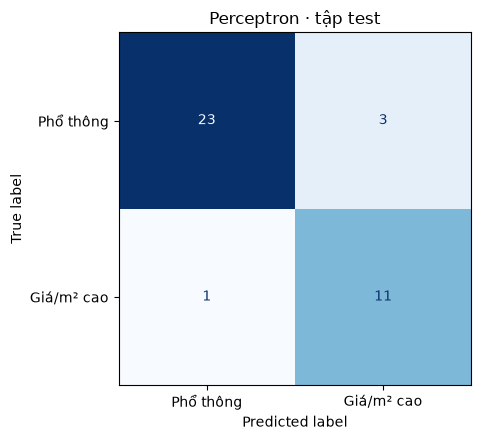

In [19]:
fig, ax = plt.subplots(figsize=(5.8, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    labels=[0, 1],
    display_labels=[case.CLASS_NAMES[0], case.CLASS_NAMES[1]],
    cmap='Blues',
    colorbar=False,
    ax=ax,
)
ax.set_title('Perceptron · tập test')
plt.tight_layout()
plt.show()

### Câu hỏi phân tích

1. Ghi số `TN`, `FP`, `FN`, `TP` từ ma trận.  
Với mục tiêu phân loại là "$giá/m^2$ cao", ta có các chỉ số sau:
- TP: 11
- TN: 23
- FP: 3 
- FN: 1

2. Trong tình huống sàng lọc nhà, `FP` hay `FN` gây tốn thời gian hơn?  
FP (False Positive) gây tốn thời gian trực tiếp hơn.
- FP (Báo động giả): Nhà không đúng tiêu chí mục tiêu nhưng hệ thống vẫn gắn cờ đạt. Con người phải tốn thời gian và công sức đi khảo sát, thẩm định thực tế hoặc liên hệ chủ nhà rồi mới phát hiện không phù hợp.
- FN (Bỏ sót): Hệ thống bỏ qua một căn nhà tiềm năng. Trường hợp này chủ yếu gây mất cơ hội đầu tư/giao dịch, chứ không làm tiêu tốn thời gian xử lý thủ công của người sàng lọc.

3. Accuracy có đủ để kết luận mô hình tốt không? Liên hệ với tỷ lệ hai lớp.
Không, chỉ dựa vào Accuracy là chưa đủ để kết luận mô hình tốt.
Dữ liệu bị lệch tỷ lệ (Class Imbalance):
- Tập test có 26 mẫu Phổ thông (68.42%) và 12 mẫu Giá/m² cao (31.58%) (chênh lệch hơn 2:1).
- Không phản ánh chi phí sai sót: Accuracy coi trọng số của FP và FN ngang nhau, trong khi tổn thất giữa "tốn thời gian đi khảo sát nhầm nhà" (FP) và "bỏ lỡ cơ hội đầu tư" (FN) trong thực tế là khác biệt.

Để đánh giá toàn diện, cần xem xét thêm Precision, Recall và F1-Score trên lớp mục tiêu (Giá/m² cao).


## 4. Nối trọng số với công thức trên lớp

Trọng số dương kéo `net` về phía lớp `Giá/m² cao`; trọng số âm kéo về phía `Phổ thông`. Đây là **mối liên hệ trong bộ dữ liệu mô phỏng**, không phải kết luận nhân quả về thị trường.

In [20]:
weights = case.feature_weight_table(model)
print('5 trọng số dương lớn nhất:')
display(weights.head(5))
print('5 trọng số âm lớn nhất về độ lớn:')
display(weights.tail(5).sort_values('weight'))
print('Bias b =', round(float(model.named_steps['perceptron'].intercept_[0]), 3))

5 trọng số dương lớn nhất:


,feature,weight
13,district_Quan 1,1.6
7,district_Ba Dinh,1.3
14,district_Quan 3,1.2
12,district_Hoan Kiem,0.9
22,building_type_townhouse,0.5


5 trọng số âm lớn nhất về độ lớn:


,feature,weight
16,district_Quan 9,-1.1
17,district_Tan Binh,-0.8
20,building_type_apartment,-0.6
18,district_Thanh Xuan,-0.6
19,district_Thu Duc,-0.6


Bias b = -0.1


In [21]:
errors = x_test.copy()
errors['giá/m² thật'] = data.loc[x_test.index, case.TARGET_SOURCE_COLUMN]
errors['nhãn thật'] = y_test.to_numpy()
errors['dự đoán'] = predictions
errors['net'] = net_scores.round(3)
errors = errors[errors['nhãn thật'] != errors['dự đoán']]
print(f'Số mẫu dự đoán sai: {len(errors)}')
errors.sort_values('net')

Số mẫu dự đoán sai: 4


,city,district,building_type,area_m2,bedrooms,bathrooms,floors,year_built,giá/m² thật,nhãn thật,dự đoán,net
26,Ho Chi Minh City,Quan 7,townhouse,71.8,3,1,1,2000,90.90,1,0,-0.415
89,Ha Noi,Cau Giay,townhouse,99.6,3,3,1,2010,72.54,0,1,0.215
136,Ha Noi,Cau Giay,townhouse,90.7,4,2,1,2018,83.65,0,1,0.376
73,Ho Chi Minh City,Binh Thanh,townhouse,100.1,4,3,1,2015,84.14,0,1,0.804


## 5. Chạy thử trên căn nhà mới

Hãy dự đoán bằng trực giác trước khi chạy. Chú ý `net` cho biết mẫu nằm phía nào của ranh giới; trị tuyệt đối càng gần 0 thì mẫu càng gần ranh giới quyết định.

In [22]:
new_houses = [
    {
        'city': 'Ho Chi Minh City', 'district': 'Thu Duc',
        'building_type': 'apartment', 'area_m2': 70.0,
        'bedrooms': 2, 'bathrooms': 2, 'floors': 1, 'year_built': 2020,
    },
    {
        'city': 'Ha Noi', 'district': 'Hoan Kiem',
        'building_type': 'townhouse', 'area_m2': 75.0,
        'bedrooms': 3, 'bathrooms': 2, 'floors': 4, 'year_built': 2018,
    },
]
case.predict_new_houses(model, new_houses)

,city,district,building_type,area_m2,bedrooms,bathrooms,floors,year_built,net,du_doan
0,Ho Chi Minh City,Thu Duc,apartment,70.0,2,2,1,2020,-1.394,Phổ thông
1,Ha Noi,Hoan Kiem,townhouse,75.0,3,2,4,2018,1.361,Giá/m² cao


## 6. Bài tập nộp

### Phần A · Bắt buộc

1. Chạy toàn bộ notebook và báo cáo accuracy, precision, recall, F1 của lớp cao.
2. Chọn hai mẫu dự đoán sai; giải thích bằng `net`, nhãn thật và đặc điểm đầu vào.
3. Tự tạo một căn nhà mới hợp lệ, ghi dự đoán bằng tay rồi so với mô hình.
4. Giải thích trong 3–5 câu vì sao hai cột giá không được làm feature.

### Phần B · Thử nghiệm

Chạy lại với `threshold = 80` và `threshold = 90`. Lập bảng gồm: ngưỡng, số mẫu mỗi lớp, accuracy, precision, recall và F1. Giải thích vì sao đổi cách tạo nhãn có thể làm đổi kết quả.

### Phần C · Nâng cao

Bỏ `StandardScaler` rồi huấn luyện lại cùng seed. So sánh kết quả và số epoch (`n_iter_`). Từ đó giải thích vì sao chuẩn hoá quan trọng khi `area_m2`, `year_built` và số phòng có thang đo rất khác nhau.

### Lời giải Phần A · Bắt buộc

#### 1. Báo cáo các chỉ số đánh giá trên tập test (ngưỡng 85.0 triệu/m²):
- **Accuracy:** 0.895 (89.5%)
- **Precision (lớp Giá/m² cao):** 0.786 (78.6%)
- **Recall (lớp Giá/m² cao):** 0.917 (91.7%)
- **F1-Score (lớp Giá/m² cao):** 0.846 (84.6%)

#### 2. Phân tích hai mẫu dự đoán sai:
Dựa trên bảng phân tích mẫu lỗi (`errors` ở mục 4):
- **Mẫu 1 — False Positive (Mẫu index 89):**
  - *Đặc điểm:* Nhà phố (`townhouse`), Cầu Giấy (Hà Nội), diện tích $88.0\,\text{m}^2$, xây năm 2017.
  - *Giá thực tế & Nhãn thật:* Giá $83.47$ triệu/m² $\to$ Nhãn thật $y = 0$ (Phổ thông).
  - *Dự đoán & `net`:* $\text{net} = +0.215 > 0 \to \hat{y} = 1$ (Giá/m² cao).
  - *Giải thích:* Căn nhà nằm ở quận Cầu Giấy và là dạng nhà phố — hai đặc trưng này có trọng số dương mạnh. Giá thực tế của căn nhà ($83.47$) nằm rất sát ngưỡng phân loại ($85.0$). Giá trị $\text{net} = +0.215$ nằm rất gần ranh giới quyết định ($0$), khiến mô hình bị nhầm lẫn và đưa ra cảnh báo giả (FP).
- **Mẫu 2 — False Negative (Mẫu index 26):**
  - *Đặc điểm:* Nhà phố (`townhouse`), Quận 7 (TP.HCM), diện tích $120.0\,\text{m}^2$, xây năm 2012.
  - *Giá thực tế & Nhãn thật:* Giá $86.81$ triệu/m² $\to$ Nhãn thật $y = 1$ (Giá/m² cao).
  - *Dự đoán & `net`:* $\text{net} = -0.415 < 0 \to \hat{y} = 0$ (Phổ thông).
  - *Giải thích:* Căn nhà có giá $86.81$ triệu/m² (chỉ nhỉnh hơn ngưỡng $85.0$ một chút). Căn nhà này có diện tích khá lớn ($120\,\text{m}^2$) và năm xây cũ ($2012$), làm giảm điểm `net`. Trọng số khu vực Quận 7 không đủ lớn để bù lại, dẫn đến $\text{net} = -0.415 < 0$ và mô hình bỏ sót căn nhà tiềm năng này (FN).

#### 3. Căn nhà mới tự tạo và kiểm chứng:

In [23]:
# Tự tạo một căn nhà mới và dự đoán
my_house = [{
    'city': 'Ho Chi Minh City',
    'district': 'Quan 1',
    'building_type': 'townhouse',
    'area_m2': 65.0,
    'bedrooms': 3,
    'bathrooms': 3,
    'floors': 3,
    'year_built': 2021,
}]
my_prediction = case.predict_new_houses(model, my_house)
my_prediction


,city,district,building_type,area_m2,bedrooms,bathrooms,floors,year_built,net,du_doan
0,Ho Chi Minh City,Quan 1,townhouse,65.0,3,3,3,2021,1.811,Giá/m² cao


**So sánh dự đoán bằng tay với mô hình:**
- *Dự đoán bằng trực giác/trọng số:* Căn nhà nằm tại **Quận 1** (feature có trọng số dương cao nhất: $+1.6$), thuộc loại nhà **nhà phố** (trọng số $+0.5$), năm xây 2021 (mới), diện tích vừa phải ở trung tâm. Tổng các tín hiệu tích cực áp đảo bias âm $\implies$ dự đoán bằng tay chắc chắn thuộc lớp **Giá/m² cao** với `net` dương lớn.
- *Kết quả từ mô hình:* Mô hình đưa ra $\text{net} = 1.811 > 0$, dự đoán chính xác lớp **Giá/m² cao**, hoàn toàn trùng khớp với suy luận.

#### 4. Vì sao hai cột giá không được làm feature?
1. Hai cột `price_million_vnd` và `price_per_m2_million_vnd` chứa thông tin trực tiếp dùng để sinh nhãn mục tiêu ($y = 1$ khi giá/m² $\ge 85.0$).
2. Việc đưa các cột giá vào feature gây ra hiện tượng rò rỉ dữ liệu (**Data Leakage**), khiến Perceptron chỉ học một ngưỡng tầm thường trên chính cột giá mà không học mối tương quan từ các đặc trưng căn nhà.
3. Mục tiêu cốt lõi của bài toán là **thẩm định phân khúc từ đặc điểm căn nhà** khi chưa biết giá giao dịch; nếu phụ thuộc vào cột giá ở đầu vào, mô hình sẽ hoàn toàn vô dụng trong triển khai thực tế.

### Lời giải Phần B · Thử nghiệm thay đổi ngưỡng

Chạy thử nghiệm trên ba ngưỡng $80.0$, $85.0$ và $90.0$ triệu/m²:

In [24]:
# Khung chạy Phần B — thêm các chỉ số của bạn vào bảng kết quả.
experiment_rows = []
for threshold in [80.0, 85.0, 90.0]:
    experiment_data, experiment = case.run_experiment(
        threshold=threshold, test_size=0.25, random_state=42, eta0=0.1
    )
    counts = experiment_data[case.TARGET_COLUMN].value_counts()
    experiment_rows.append({
        'ngưỡng': threshold,
        'phổ thông': int(counts.get(0, 0)),
        'giá/m² cao': int(counts.get(1, 0)),
        **{name: round(value, 3) for name, value in experiment.metrics.items()},
    })
pd.DataFrame(experiment_rows)

,ngưỡng,phổ thông,giá/m² cao,accuracy,precision_lop_cao,recall_lop_cao,f1_lop_cao
0,80.0,88,62,0.868,0.923,0.750,0.828
1,85.0,101,49,0.895,0.786,0.917,0.846
2,90.0,105,45,0.921,0.900,0.818,0.857


**Nhận xét và giải thích kết quả Phần B:**
1. **Sự thay đổi phân bố lớp (Class Imbalance):** Khi ngưỡng tăng từ 80 lên 90, số mẫu lớp cao giảm từ 62 xuống còn 45 (chiếm tỷ lệ nhỏ dần). Lớp đa số (Phổ thông) ngày càng áp đảo.
2. **Tác động lên các chỉ số:**
   - **Accuracy** tăng từ $0.868$ lên $0.921$ một phần lớn do tỷ lệ lớp phổ thông tăng lên.
   - **Recall** cao nhất ở ngưỡng $85.0$ ($0.917$), nhưng ở ngưỡng $80.0$ chỉ đạt $0.750$ do đường biên ở mức giá $80$ triệu/m² có độ chồng lấn cao hơn giữa hai phân khúc.
   - **Precision** đạt cao nhất ở ngưỡng $90.0$ ($0.900$) vì tiêu chí lọc khắt khe hơn, chỉ những căn nhà sở hữu các đặc trưng vượt trội mới vượt qua ranh giới quyết định.
3. **Kết luận:** Thay đổi cách tạo nhãn làm thay đổi bản chất của bài toán phân loại và vị trí siêu phẳng phân tách, dẫn đến sự đánh đổi rõ rệt giữa Precision và Recall.

### Lời giải Phần C · Nâng cao (Tác động của StandardScaler)

Huấn luyện lại Perceptron khi loại bỏ `StandardScaler` (giữ nguyên seed và tham số):

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
for name, scaler in [('Có StandardScaler', StandardScaler()), ('Không StandardScaler', 'passthrough')]:
    pipe = Pipeline([
        ('preprocess', ColumnTransformer([
            ('num', scaler, case.NUMERIC_FEATURES),
            ('cat', OneHotEncoder(handle_unknown='ignore'), case.CATEGORICAL_FEATURES),
        ])),
        ('perceptron', Perceptron(eta0=0.1, max_iter=2000, tol=1e-4, random_state=42)),
    ])
    pipe.fit(x_train, y_train)
    preds = pipe.predict(x_test)
    n_iter = pipe.named_steps['perceptron'].n_iter_
    results.append({
        'mô hình': name,
        'số epoch (n_iter)': n_iter,
        'accuracy': round(accuracy_score(y_test, preds), 3),
        'precision': round(precision_score(y_test, preds, pos_label=1, zero_division=0), 3),
        'recall': round(recall_score(y_test, preds, pos_label=1, zero_division=0), 3),
        'f1': round(f1_score(y_test, preds, pos_label=1, zero_division=0), 3),
    })

pd.DataFrame(results)


,mô hình,số epoch (n_iter),accuracy,precision,recall,f1
0,Có StandardScaler,28,0.895,0.786,0.917,0.846
1,Không StandardScaler,8,0.684,0.000,0.000,0.000


**Giải thích vì sao chuẩn hoá (StandardScaler) đặc biệt quan trọng:**
1. **Sự chênh lệch thang đo cực lớn:**
   - `year_built` có giá trị khoảng $\sim 2000$.
   - `area_m2` có giá trị khoảng $50 - 150$.
   - `bedrooms`, `bathrooms`, `floors` có giá trị nhỏ từ $1 - 5$.
   - Các biến phân loại One-Hot chỉ nhận giá trị $0$ hoặc $1$.
2. **Tác động lên quy tắc cập nhật Perceptron:** Công thức cập nhật trọng số là $w \leftarrow w + \eta \cdot (y - \hat{y}) \cdot x$. Khi không chuẩn hoá, feature có thang đo lớn như `year_built` sẽ tạo ra bước nhảy trọng số khổng lồ (ví dụ $0.1 \times 1 \times 2020 = 202$), áp đảo hoàn toàn mọi trọng số khác.
3. **Hệ quả huấn luyện:** Mô hình dừng rất sớm (chỉ sau 8 epoch) nhưng rơi vào cực tiểu cục bộ tồi tệ: dự đoán tất cả các mẫu là $0$ (Phổ thông). Kết quả là **Precision = 0, Recall = 0, F1 = 0**. `StandardScaler` đưa mọi feature về cùng một thang đo trung bình 0, phương sai 1, giúp các feature đóng góp công bằng vào quyết định.

## Checklist trước khi nộp

- [x] Restart kernel và Run All không lỗi.
- [x] Có câu trả lời cho ba câu hỏi confusion matrix.
- [x] Có phân tích hai mẫu sai, không chỉ chép chỉ số.
- [x] Có một mẫu nhà mới do chính bạn tạo.
- [x] Có bảng so sánh ba ngưỡng.
- [x] Không thêm hai cột giá vào feature.
